# CREDIT CARD CUSTOMER CHURN ANALYSIS
## ADVANCED EXPLORATORY ANALYSIS

This will explore the churn pattern accross demographic, behaviours and financial dimension to gain insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [3]:
# Load the cleaned dataset
df_BankChurn = pd.read_csv("../DataSet/Cleaned/BankChurners_Cleaned.csv")   
df_BankChurn.shape

(10127, 28)

DESCRIPTIVE STATISTICS

In [4]:
df_BankChurn.describe()[["Customer_Age","Credit_Limit","Total_Trans_Amt","Total_Trans_Ct"]]

,Customer_Age,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,8631.953698,4404.086304,64.858695
std,8.016814,9088.776650,3397.129254,23.472570
min,26.000000,1438.300000,510.000000,10.000000
25%,41.000000,2555.000000,2155.500000,45.000000
50%,46.000000,4549.000000,3899.000000,67.000000
75%,52.000000,11067.500000,4741.000000,81.000000
max,73.000000,34516.000000,18484.000000,139.000000


The dataset contains 10,127 credit card customers.
Customer ages range from 26 to 73 years, with an average age of approximately 46 years.
Credit limits vary widely, ranging from £1,438 to £34,516, indicating a diverse customer base with different credit capacities.
Transaction amounts also show significant variation, with customers spending between £510 and £18,484 annually.
On average, customers make about 65 transactions per year, with some making as few as 10 and others up to 139.
These statistics confirm a broad spread in customer financial behaviour, supporting further segmentation and churn analysis.

In [5]:
# Churcn Distribution
df_BankChurn["Churn_Flag"].value_counts()   


Churn_Flag
0    8500
1    1627
Name: count, dtype: int64

In [6]:
(df_BankChurn["Churn_Flag"].value_counts(normalize=True) * 100).round(2) # calculating the percentage of churners and non-churners in the dataset, and rounded to 2 decimal places


Churn_Flag
0    83.93
1    16.07
Name: proportion, dtype: float64

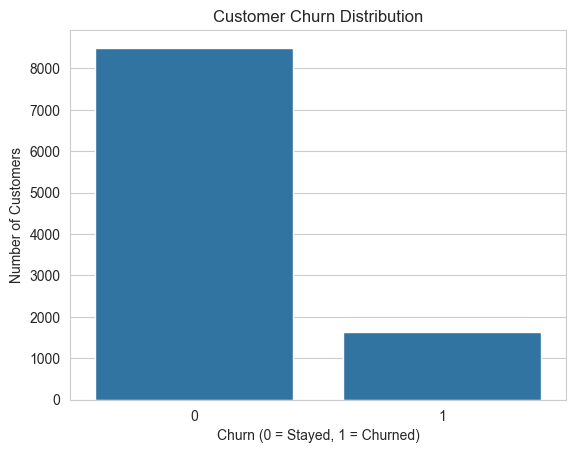

In [7]:
# Churn Chart
sns.countplot(x="Churn_Flag", data=df_BankChurn)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

## Churn Distribution Insight
It shows that 16.1% of the customers have churned while 83.93% remain active. Although the majority of the customer are still existing, the churn proportion is a significant revenue risk which needs further investigation into the drivers of churn.

In [8]:
# Churn by Gender crosstab
churn_gender = pd.crosstab(df_BankChurn["Gender"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_gender.round(2)   


Churn_Flag,0,1
Gender,,
F,82.64,17.36
M,85.38,14.62


In [9]:
# Gender Churn 
churn_gender = pd.crosstab(df_BankChurn["Gender"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_gender.round(2)

Churn_Flag,0,1
Gender,,
F,82.64,17.36
M,85.38,14.62


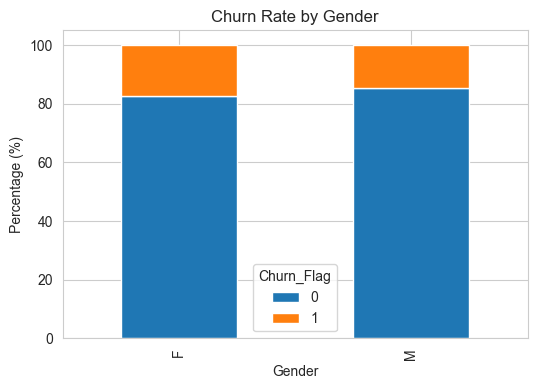

In [10]:
# Gender Churn Graph
churn_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Rate by Gender")
plt.ylabel("Percentage (%)")
plt.show()

## Churn by Gender Insight
I observed that female customers have a slightly higher churn rate than male customers.

While the gap is not very large, it highlights a possible difference in customer experience or engagement levels. 

In [11]:
# Churn by Age Band crosstab
churn_age = pd.crosstab(df_BankChurn["Age_Band"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_age.round(2)

Churn_Flag,0,1
Age_Band,,
18-30,87.92,12.08
31-40,85.46,14.54
41-50,83.25,16.75
51-60,83.24,16.76
60+,85.68,14.32


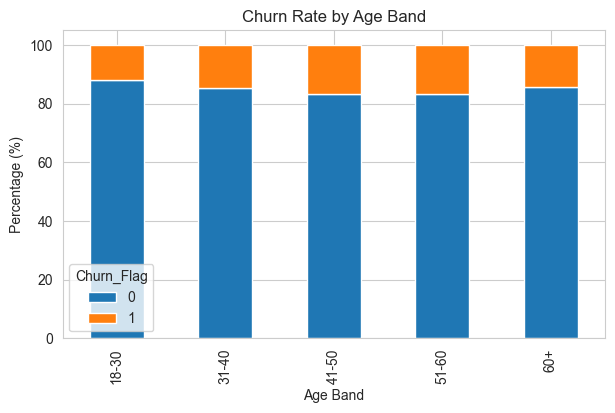

In [12]:
# Churn by Age Graph 
churn_age.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Churn Rate by Age Band")
plt.ylabel("Percentage (%)")
plt.xlabel("Age Band")

plt.show()

## Churn by Age Band Insight
From the Analysis and the graph, churns rates appear to increase as customer get older before dropping slighly after 60. 
Customer between 41 and 60 years show the highest churn levels, while Younger customers are more likely to stay, suggesting they are more engaged or still building relationship with the bank

In [13]:
# Churn by Tenure Band crosstab
churn_tenure = pd.crosstab(df_BankChurn["Tenure_Band"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_tenure.round(2)

Churn_Flag,0,1
Tenure_Band,,
1-2 years,85.12,14.88
2-3 years,83.92,16.08
3-4 years,83.82,16.18
4+ years,83.05,16.95


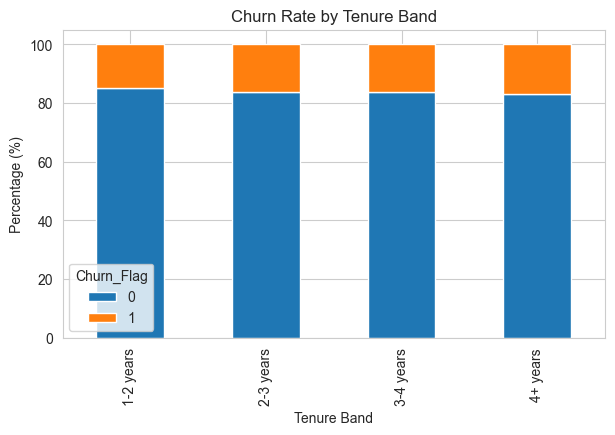

In [14]:
# Churn by Tenure Graph
churn_tenure.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Churn Rate by Tenure Band")
plt.ylabel("Percentage (%)")
plt.xlabel("Tenure Band")

plt.show()

## Churn by Tenure Band Insight
The analysis shows that churn increases as customer tenure increases.
Customers who have been with the bank for 1–2 years have the lowest churn rate (14.88%), while those with over 4 years of tenure have the highest churn rate (16.95%).
This may indicate declining satisfaction,long time customer may become disengaged over time, or may be attracted by better offers from competitors. Highlighting the importance of loyalty and retention initiatives.


### Demographic Churn Summary
Demographic analysis shows that churn varies across different customer groups.
Female customers have a slightly higher churn rate compared to male customers.
Churn increases with age, with customers aged 41–60 showing the highest attrition levels.
Tenure analysis also reveals that long-term customers are more likely to churn than newer customers.


In [15]:
# Activity_Level by Churn crosstab
activity_churn = pd.crosstab(df_BankChurn["Activity_Level"], df_BankChurn["Churn_Flag"], normalize="index") * 100
activity_churn.round(2)

Churn_Flag,0,1
Activity_Level,,
High,98.78,1.22
Low,68.47,31.53
Medium,82.53,17.47


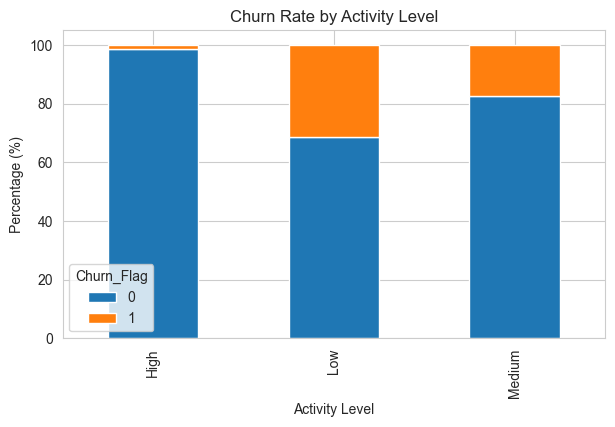

In [16]:
# Activity_Level by Churn Graph
activity_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Churn Rate by Activity Level")
plt.ylabel("Percentage (%)")
plt.xlabel("Activity Level")

plt.show()

## Activity Level by Churn Insight
From the analysis, customer activity has a strong relationship with churn.
Customer who use their card more tend to stay,have the lowest churn risk, suggesting that engagement and card usage play a critical role in customer retention. while those who use them less are more likely to churn.
Low activity customers represent the highest risk group for churn, compared to medium and highly active customers.
This strongly supports the hypothesis that lower engagement increases the likelihood of churn.


In [17]:
# Utilisation by Churn crosstab
utilisation_churn = pd.crosstab(df_BankChurn["Utilisation_Segment"], df_BankChurn["Churn_Flag"], normalize="index") * 100
utilisation_churn.round(2)

Churn_Flag,0,1
Utilisation_Segment,,
High,87.06,12.94
Low,79.56,20.44
Medium,92.47,7.53


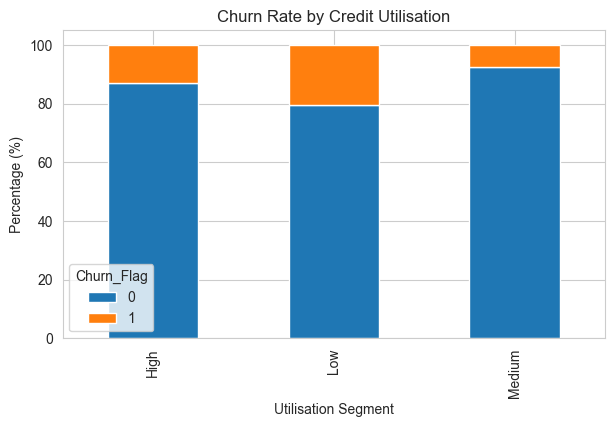

In [18]:
# Utilisation by Churn Graph
utilisation_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Churn Rate by Credit Utilisation")
plt.ylabel("Percentage (%)")
plt.xlabel("Utilisation Segment")

plt.show()

## Utilisation by Churn Insight
The analysis show that customer with low credit utilisation have the highest churn rate (20%). Customer with medium utilisation have the lowest churn rate about(8%). 
This suggests that customers who rarely use their credit cards are less engaged and more likely to leave the bank.
On the other hand, customers with moderate utilisation appear more stable and loyal to the bank.

In [19]:
# Spend Drop by Churn crosstab
spend_churn = pd.crosstab(df_BankChurn["Spend_Drop_Flag"], df_BankChurn["Churn_Flag"], normalize="index") * 100 
spend_churn.round(2)    

Churn_Flag,0,1
Spend_Drop_Flag,,
0,85.80,14.20
1,83.73,16.27


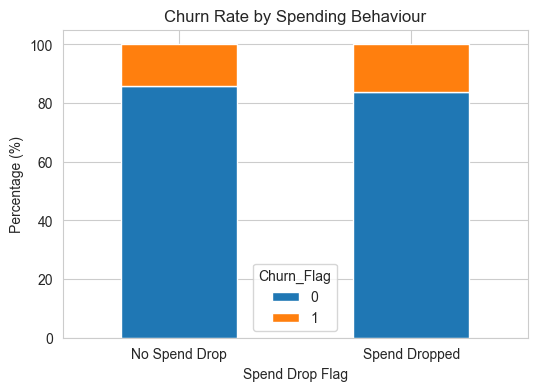

In [20]:
# Spend Drop by Churn Graph
spend_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Rate by Spending Behaviour")
plt.ylabel("Percentage (%)")
plt.xlabel("Spend Drop Flag")

plt.xticks([0,1], ["No Spend Drop", "Spend Dropped"], rotation=0)

plt.show()

## Spend Drop by Churn Insight
From the analysis and the graph, customers whose spending dropped from Q4 to Q1 show a slighly higher churn rate (16.27%) compared to those whose spending do not drop (14.20%).
However the difference is small, so spending drop alone may not strongly predict churn but may signal early disengagement and the impact on churn is moderate compared to other behavioural factors.


In [21]:
# Transaction Drop by Churn crosstab
transaction_churn = pd.crosstab(df_BankChurn["Transaction_Drop_Flag"], df_BankChurn["Churn_Flag"], normalize="index") * 100
transaction_churn.round(2)  

Churn_Flag,0,1
Transaction_Drop_Flag,,
0,92.93,7.07
1,83.13,16.87


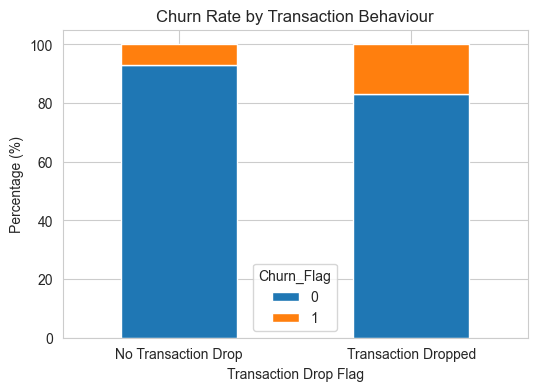

In [22]:
# Transaction  Drop by Churn Graph
transaction_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Rate by Transaction Behaviour")
plt.ylabel("Percentage (%)")
plt.xlabel("Transaction Drop Flag")

plt.xticks([0,1], ["No Transaction Drop", "Transaction Dropped"], rotation=0)

plt.show()

## Transaction Drop by Churn Insight
Customer whose transaction activity dropped show  significantly higher churn rate (16.87%), compared to those whose transactions did not drop (7.07%).
This suggests that declining card usage is a strong behavioural signal of disengagement and warning sign for churn.

### Behavioural Churn Summary
Behavioural features show the strongest relationship with churn.
Low activity customers show the highest churn risks, followed by low credit utilisation transaction drop frequency.
Spend Drop shows a small but still noticeable relationship with attrition

## Generate Correlation Heatmap
This will help to identify which numerical features relates to churn, and the  strong predictors for modelling. This will show how strongly each variabl moves with churn.
+1 → Strong positive relationship
 0 → No relationship
-1 → Strong negative relationship

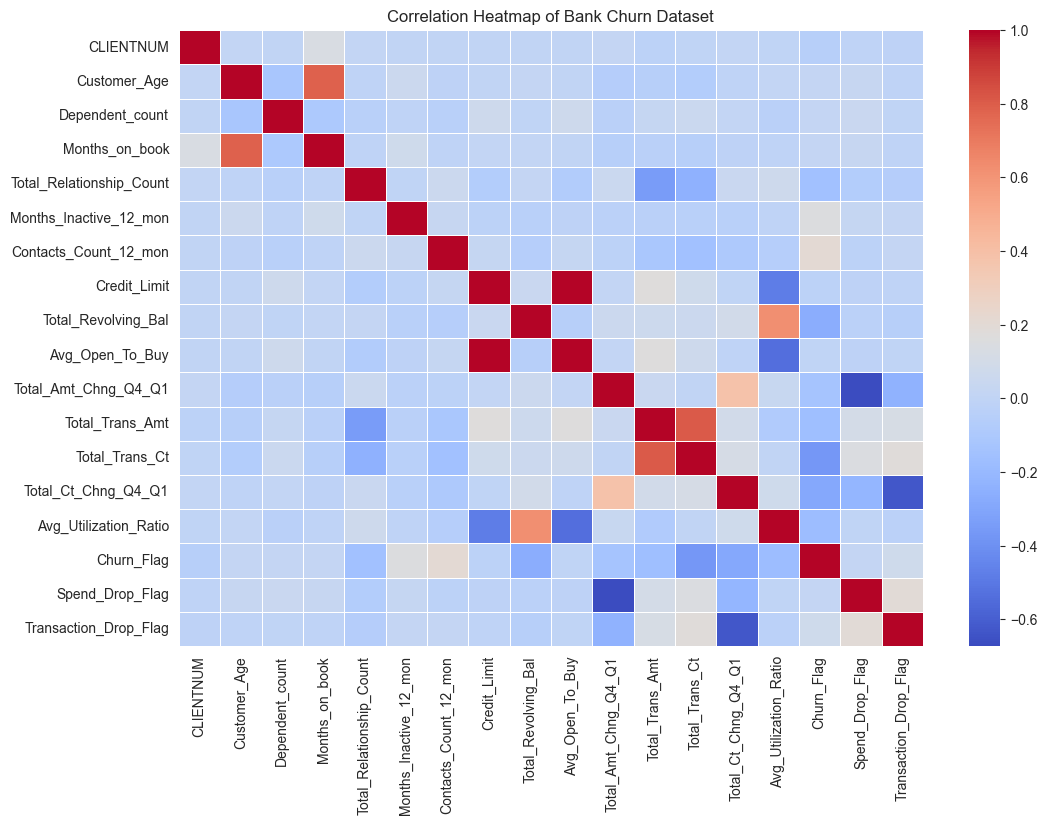

In [23]:
# Creating a correlation Heatmap
plt.figure(figsize=(12, 8)) 
sns.heatmap(df_BankChurn.corr(numeric_only=True), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of Bank Churn Dataset")    
plt.show()  

In [24]:
# Focused Churn Correlation Heatmap

churn_corr = (df_BankChurn.corr(numeric_only=True)["Churn_Flag"].sort_values(ascending=False))
churn_corr 

Churn_Flag                  1.000000
Contacts_Count_12_mon       0.204491
Months_Inactive_12_mon      0.152449
Transaction_Drop_Flag       0.073353
Dependent_count             0.018991
Customer_Age                0.018203
Spend_Drop_Flag             0.016820
Months_on_book              0.013687
Avg_Open_To_Buy            -0.000285
Credit_Limit               -0.023873
CLIENTNUM                  -0.046430
Total_Amt_Chng_Q4_Q1       -0.131063
Total_Relationship_Count   -0.150005
Total_Trans_Amt            -0.168598
Avg_Utilization_Ratio      -0.178410
Total_Revolving_Bal        -0.263053
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Trans_Ct             -0.371403
Name: Churn_Flag, dtype: float64

### CORRELATION ANALYSIS INTERPRETAION 
Correlation analysis was conducted to identify relationships between customer attributes and churn behaviour.
Behavioural variables showed stronger relationships with churn compared to demographic factors.
Transaction count demonstrated the strongest negative correlation with churn (-0.37), indicating that customers who transact more frequently are less likely to leave.
Similarly, transaction change and revolving balance also showed moderate negative correlations, suggesting that active credit usage reduces churn risk.
On the other hand, inactivity-related variables such as contacts count (0.20) and months inactive (0.15) showed positive correlations with churn, indicating that disengaged customers are more likely to churn.
Overall, engagement and usage behaviours appear to be more influential churn drivers than demographic characteristics.


### HYPOTHESIS TESTING 

HYPOTHESIS 1
Statement: Customers with lower engagement (low spending, fewer transactions) are more likely to churn
Validation: The hypothesis will be tested using boxplots between churned and retained customers, supported by statistical testing and machine learning feature importance analysis


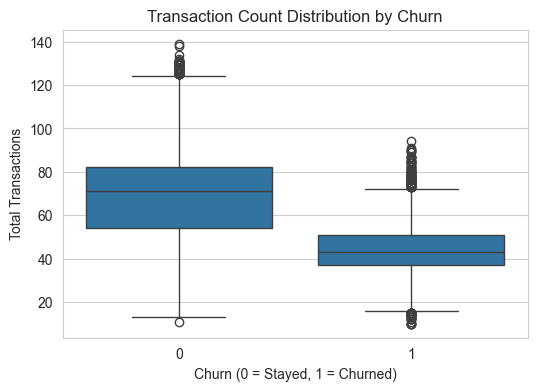

In [25]:
# BOXPLOT 1 - Transaction Count by Churn 
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn_Flag",
    y="Total_Trans_Ct",
    data=df_BankChurn
)

plt.title("Transaction Count Distribution by Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Total Transactions")

plt.show()

Customers who stayed (Churn = 0) have a much higher number of transactions compared to customers who churned (Churn = 1).
The median transaction count for retained customers is significantly higher, showing they use their card more frequently

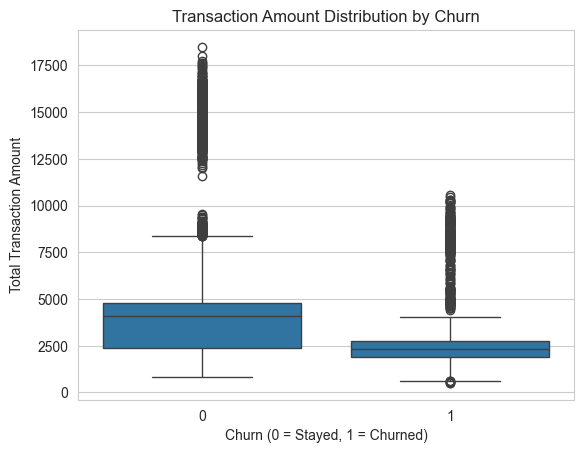

In [26]:
# BOXPLOT 2 - Tansaction Amount by Churn 
sns.boxplot(
    x="Churn_Flag",
    y="Total_Trans_Amt",
    data=df_BankChurn
)

plt.title("Transaction Amount Distribution by Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Total Transaction Amount")

plt.show()

Customers who stayed spend significantly more than those who churned.
The median transaction amount for retained customers is noticeably higher, while churned customers show lower spending behaviour.

### Hypothesis 1 Visual Validation Summary
The boxplots clearly show that customers who churn have lower transaction counts and lower spending levels compared to retained customers. This indicates that reduced engagement, both in frequency and value of transactions is strongly associated with churn behaviour. This supports the hypothesis that reduced customer engagement is a key driver of churn risk.

STATISTICAL TESTING

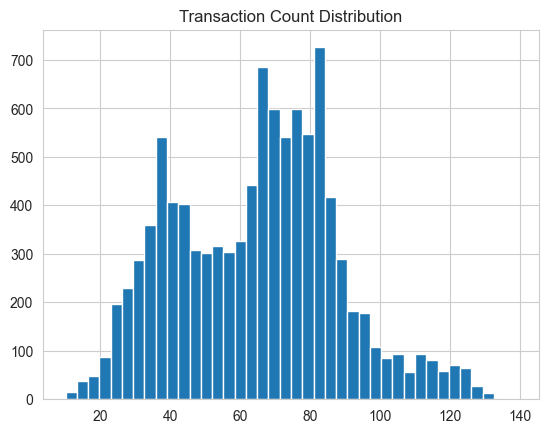

In [27]:
# Testing for Normality
plt.hist(df_BankChurn["Total_Trans_Ct"], bins=40)
plt.title("Transaction Count Distribution")
plt.show()

## Mann Whitney U Test: 
I will use Mann–Whitney U Test to compare:both the Transaction counts of Churned customers and Transaction counts of retained customer
The rational for using this test was The distribution of transaction counts and spending amounts was assessed visually using histograms and boxplots. The data showed right-skewness and multiple outliers, indicating deviation from normality. Therefore, the non-parametric Mann–Whitney U test was used instead of a t-test.


In [28]:
# Testing using Mann Whitney U Test

from scipy.stats import mannwhitneyu

churned = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 1
]["Total_Trans_Ct"]

stayed = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 0
]["Total_Trans_Ct"]

In [29]:
stat, p_value = mannwhitneyu(
    churned,
    stayed,
    alternative="two-sided"
)

p_value

0.0

## Statistical Interpretation
Null Hypothesis (H₀)
There is no difference in transaction counts between churned and retained customers.

Alternative Hypothesis (H₁)
There is a difference in transaction counts between the two groups.

Decision Rule

If p-value < 0.05 → Reject H₀


Since the p_value ≈ 0.000
so Reject the null hypothesis.

The Mann–Whitney U test shows a statistically significant difference in transaction counts between churned and retained customers (p < 0.05). This indicates that customer engagement, measured by transaction frequencycountd, has a strong relationship with churn behaviour.

In [30]:
# Mann Whitney U Test 
churned_amt = df_BankChurn[df_BankChurn["Churn_Flag"] == 1]["Total_Trans_Amt"]
stayed_amt  = df_BankChurn[df_BankChurn["Churn_Flag"] == 0]["Total_Trans_Amt"]

stat, p_value = mannwhitneyu(churned_amt, stayed_amt, alternative="two-sided")

p_value

2.719009390771486e-112

A Mann–Whitney U test was conducted to compare total transaction amounts between churned and retained customers.

The test returned a p-value of 2.72e-112, which is significantly below the 0.05 threshold. This indicates a statistically significant difference in transaction amounts between the two groups.

Customers who churn tend to have lower transaction amounts, supporting the hypothesis that lower engagement is associated with higher churn risk.

## Hypothesis 2 
Statement: Demographic factors such as age, income, and marital status influence churn likelihood.
Validation: I will use interactive Bar Chart and Logistic Regression Coefficients

## Income by Churn Test

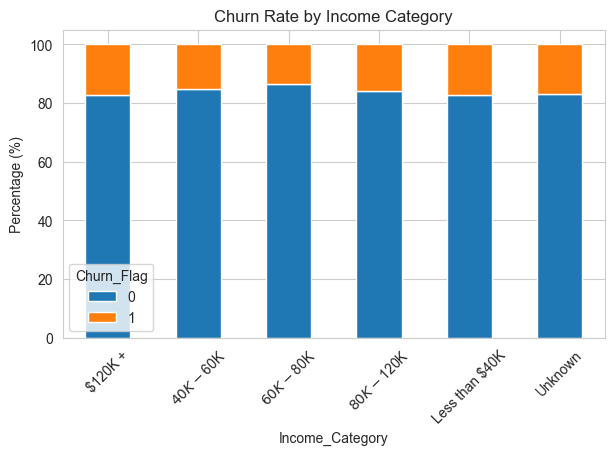

In [31]:
# Calculating the income by churn crosstab and plotting the graph to test the income category.
income_churn = pd.crosstab(
    df_BankChurn["Income_Category"],
    df_BankChurn["Churn_Flag"],
    normalize="index"
) * 100

income_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Churn Rate by Income Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

## Income by Churn Insight
From the churn distribution by income category, I observed that churn exists across all income groups but at slightly different rates.
Customers earning between $60K–$80K show the lowest churn rate, meaning they are the most stable segment.
Customers earning less than $40K and those in the unknown income category show relatively higher churn rates.
Interestingly, even high-income customers ($120K+) still churn, although at a slightly lower rate compared to lower income groups.
Overall, income appears to influence churn behaviour, but the difference is moderate rather than extreme.
Low income → more likely to churn

Mid income is most stable

High income is  valuable but still at risk

So retention strategy should include:

Rewards for mid-income loyalty, Financial flexibility for low-income and Premium perks for high-income


## Marital Status by Churn 

In [ ]:
# Marital Status by Churn Crosstab
marital_churn = pd.crosstab(df_BankChurn["Marital_Status"],df_BankChurn["Churn_Flag"],normalize="index") * 100
marital_churn.round(2)  

Churn_Flag,0,1
Marital_Status,,
Divorced,83.82,16.18
Married,84.87,15.13
Single,83.06,16.94
Unknown,82.78,17.22


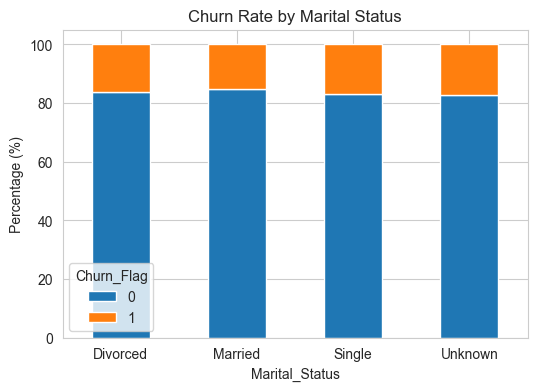

In [36]:
#Marital Status by Churn Graph
marital_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn Rate by Marital Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

## Marital Status by Churn Insight
From the churn distribution by marital status, I observed that single customers have the highest churn rate compared to other groups.
Married customers show slightly lower churn, indicating they are more stable and likely to remain with the bank.
Divorced customers fall in between, while customers with unknown marital status also show relatively higher churn.
Overall, marital status appears to influence churn behaviour, with single customers being the most at-risk segment.

### Hypothesis 2 Visual Validation Summary
Demographic analysis shows that churn behaviour varies across customer profiles.
Age analysis indicates that middle-aged customers (41–60) have slightly higher churn rates.
Income analysis reveals that mid-income customers are the most stable, while lower-income segments churn more frequently.
Marital status analysis shows that single customers exhibit the highest churn risk, while married customers are more retained.
These findings suggest that demographic factors do influence churn likelihood, supporting Hypothesis 2.


Logistic Regression for validating Hypothesis 2
This will statistically validate whether age, income, marital status influence churn. We want coeffients that answer: Which demographic factors increase or decrease churn risk? 
Logistic regression was selected to validate the impact of demographic variables on churn likelihood due to its suitability for binary classification problems and its ability to  interpret through coefficient analysis.

How to read coefficients

Coefficient sign	Meaning
Positive (+)	Increases churn risk
Negative (–)	Reduces churn risk
Larger magnitude	Stronger impact

In [37]:
# Selecting Demographics Features
features = [
    "Customer_Age",
    "Gender",
    "Income_Category",
    "Marital_Status"
]

X = df_BankChurn[features]
y = df_BankChurn["Churn_Flag"]

In [39]:
# Encoding Categorical Variables
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

# Spliting the Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Extracting  Coefficients
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
0,Customer_Age,0.011568
4,Income_Category_$80K - $120K,-0.010697
8,Marital_Status_Single,-0.017770
9,Marital_Status_Unknown,-0.023934
7,Marital_Status_Married,-0.123293
3,Income_Category_$60K - $80K,-0.162404
6,Income_Category_Unknown,-0.279241
5,Income_Category_Less than $40K,-0.306648
2,Income_Category_$40K - $60K,-0.341543
1,Gender_M,-0.443110


Logistic Regression validation Summary
A logistic regression model was used to validate the impact of demographic factors on churn likelihood.
Results showed that customer age had a small positive coefficient, indicating that churn risk increases slightly with age.
Gender analysis revealed that male customers are less likely to churn compared to females, as shown by a strong negative coefficient.
Income categories displayed negative coefficients, suggesting that mid-income customers are more stable relative to the reference income group.
Marital status analysis indicated that married customers have lower churn risk, supporting earlier exploratory findings.
Overall, demographic factors do influence churn behaviour, thereby supporting Hypothesis 2.

Hypothesis 3
Statement: High credit utilisation and late payments increase churn risk.
Validation: Boxplots comparing utilisation and revolving balance between churned and retained customers
Mann-Whitney U statistical test to test significance


Utilisation Boxplot

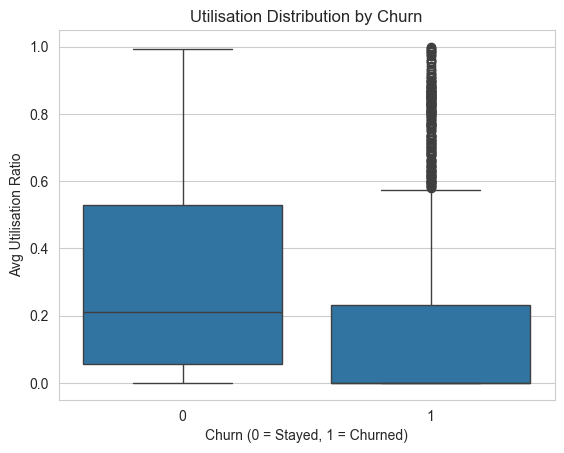

In [42]:
# Plotting Boxplot - Utilisation vs Churn
sns.boxplot(
    x="Churn_Flag",
    y="Avg_Utilization_Ratio",
    data=df_BankChurn
)
plt.title("Utilisation Distribution by Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Avg Utilisation Ratio")
plt.show()

 ## Utilisation vs Churn Boxplot Insight
 Customers who churned generally had lower credit utilisation compared to customers who stayed.
The median utilisation for churned customers is close to zero, meaning many churners were barely using their credit cards.
In contrast, retained customers show a higher median utilisation and a wider spread, indicating more active credit usage.
This suggests that customers who actively use their credit facilities are less likely to churn.

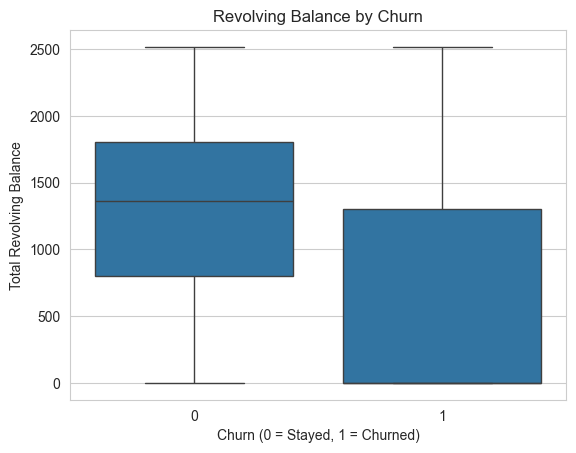

In [44]:
# BOXPLOT 2- Revolving Balance 
sns.boxplot(
    x="Churn_Flag",
    y="Total_Revolving_Bal",
    data=df_BankChurn
)
plt.title("Revolving Balance by Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Total Revolving Balance")
plt.show()

### Revolving Balance by Churn Insight 
The boxplot show that customer who stayed (0) have a higher median revolving balance while Churned customers (1) have Lower median balance, many values close to 0
This means churners are carrying less outstanding credit. Suggesting that customers with low revolving balances appear less financially engaged with the bank. Since they are not actively borrowing or revolving balances, they may feel less dependent on the credit card service, increasing their likelihood to churn.

Statistical Testing 

In [ ]:
#Mann-Whitney U Test  (Utilisation )
from scipy.stats import mannwhitneyu

# Split groups
churned_util = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 1
]["Avg_Utilization_Ratio"]

stayed_util = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 0
]["Avg_Utilization_Ratio"]

# Test
stat, p_value = mannwhitneyu(
    churned_util,
    stayed_util,
    alternative="two-sided"
)
p_value


2.8690970172667045e-129

Statistical Test Result
A Mann-Whitney U test was conducted to compare credit utilisation between churned and retained customers. The test produced a p-value of 2.87e-129, which is far below the 0.05 significance threshold.

This indicates a statistically significant difference in utilisation behaviour between the two groups.

In [48]:
# Mann Whitney U Test(Revolving Balance)
churned_bal = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 1
]["Total_Revolving_Bal"]

stayed_bal = df_BankChurn[
    df_BankChurn["Churn_Flag"] == 0
]["Total_Revolving_Bal"]

stat, p_value = mannwhitneyu(
    churned_bal,
    stayed_bal,
    alternative="two-sided"
)

p_value

1.9156786730316762e-129

Statistical Validation

Mann-Whitney U tests were conducted to compare credit utilisation and revolving balances between churned and retained customers.

The utilisation test returned a p-value of 2.87e-129, while the revolving balance test returned 1.92e-129. Both values are significantly below the 0.05 threshold, indicating statistically significant differences between the two groups.
Therefore Reject Null Hypothesis.


Hypothesis Outcome
Statistical testing confirmed that credit utilisation and revolving balance differ significantly between churned and retained customers (p < 0.05).

However, visual analysis revealed that churned customers generally exhibit lower utilisation and lower revolving balances. This indicates that reduced credit engagement,  rather than high utilisation, is associated with increased churn risk.

Therefore, the hypothesis is partially supported, as credit behaviour influences churn, but the observed direction differs from the original assumption.


Hypothesis 4
Statement : Interactive Communication tools can reduce churn risk
Validation: I will simulate "Retention Impact" 

Visual Validation
There is no direct "communication tool” column, I will use proxy variables 

Proxy variables =
Contacts_Count_12_mon
Months_Inactive_12_mon

These represent customer interaction & engagement with the bank.

In [ ]:
# Contact Vs Churn Crosstab
contacts_churn = pd.crosstab(
    df_BankChurn["Contacts_Count_12_mon"],
    df_BankChurn["Churn_Flag"],
    normalize="index"
) * 100

contacts_churn.round(2)

Churn_Flag,0,1
Contacts_Count_12_mon,,
0,98.25,1.75
1,92.80,7.20
2,87.51,12.49
3,79.85,20.15
4,77.37,22.63
5,66.48,33.52
6,0.00,100.00


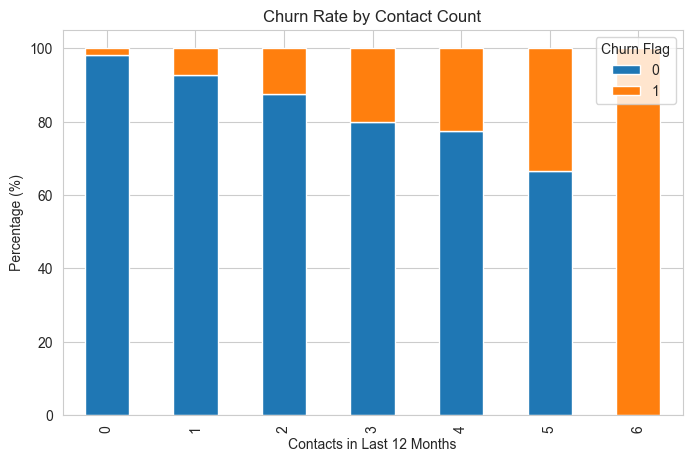

In [50]:
# Contact by Churn Graph
contacts_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Contact Count")
plt.ylabel("Percentage (%)")
plt.xlabel("Contacts in Last 12 Months")
plt.legend(title="Churn Flag")
plt.show()

Analysis of customer contact frequency shows a strong positive relationship with churn. Customers with higher numbers of contacts in the last 12 months exhibit significantly higher churn rates. This suggests that customer interactions are largely reactive, occuring  after customer begin to disgengage, or experience  service issues rather than proactive retention efforts. 
This finding suggests that earlier, proactive communication tools such as personalised alerts, chatbot engagement, and behavioural nudges could reduce churn risk before escalation occurs.
While communication is associated with churn, it does not currently appear to reduce churn risk, indicating an opportunity for proactive engagement strategies.

### Contact Segmentation Analysis 

In [56]:
# Creating Contact Groups
df_BankChurn["Contact_Level"] = pd.cut(
    df_BankChurn["Contacts_Count_12_mon"],
    bins=[-1, 1, 3, 6],
    labels=["Low Contact", "Medium Contact", "High Contact"],
    include_lowest=True
)

In [57]:
df_BankChurn["Contact_Level"].value_counts()

Contact_Level
Medium Contact    6607
Low Contact       1898
High Contact      1622
Name: count, dtype: int64

In [58]:
# Churn by Contact Level
# Testing Churn impact
contact_level_churn = pd.crosstab(
    df_BankChurn["Contact_Level"],
    df_BankChurn["Churn_Flag"],
    normalize="index"
) * 100

contact_level_churn.round(2)

Churn_Flag,0,1
Contact_Level,,
Low Contact,93.94,6.06
Medium Contact,83.59,16.41
High Contact,73.61,26.39


Contact level analysis shows a clear increase in churn risk as customer contact frequency rises.
Customers with low contact levels have the lowest churn rate at 6.06%, indicating strong retention.
Medium-contact customers show a higher churn rate of 16.41%, suggesting moderate disengagement.
High-contact customers exhibit the highest churn rate at 26.39%, highlighting a significantly at-risk group.
This pattern suggests that customer contact is largely reactive, occurring wafter disengaggement or when customers begin experiencing issues rather than preventing churn early.
Therefore, this analysis supports Hypothesis 4. 


RETENTION SIMULATION

In [60]:
# Quantifying Impact
# Assumption : If proactive communication reduces high-contact churn by 20%
current_churn = df_BankChurn["Churn_Flag"].mean() * 100

high_contact_churn = contact_level_churn.loc["High Contact", 1]

reduction = high_contact_churn * 0.20

new_churn_rate = current_churn - reduction

current_churn, new_churn_rate

(16.065962279055988, 10.788527013951178)

The current overall churn rate is 16.07%.
A retention simulation was conducted assuming proactive communication reduces churn among high-contact customers by 20%.
Under this scenario, the projected churn rate drops to 10.79%.
This represents a potential churn reduction of approximately 5.28 percentage points, demonstrating the business value of early engagement and interactive communication tools.

Retention modelling indicates that proactive communication strategies could significantly reduce customer churn.
By targeting high-risk customers with interactive tools such as alerts, personalised offers, and chatbot support, churn could potentially decline from 16.07% to 10.79%.
This highlights communication timing, not just frequency but as a critical retention lever.

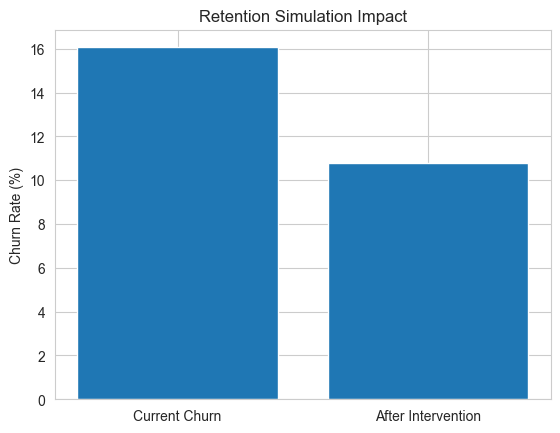

In [61]:
# Simulation Graph 
import matplotlib.pyplot as plt

rates = [16.07, 10.79]
labels = ["Current Churn", "After Intervention"]

plt.bar(labels, rates)
plt.title("Retention Simulation Impact")
plt.ylabel("Churn Rate (%)")
plt.show()